/tmp/ipykernel_2807055/4139638557.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")


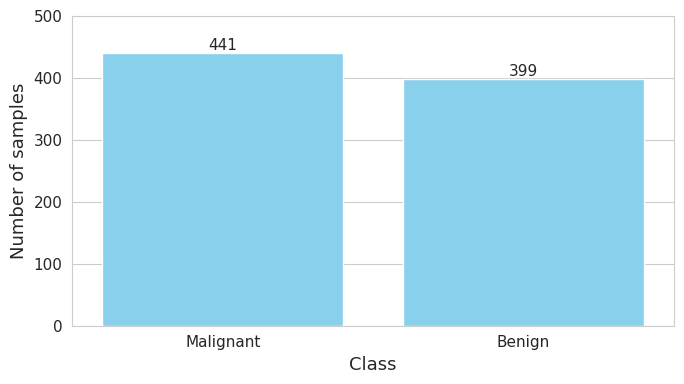

Saved histogram to: augmented_data_histograms/breast_augmented_histogram.svg


/tmp/ipykernel_2807055/4139638557.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="center")


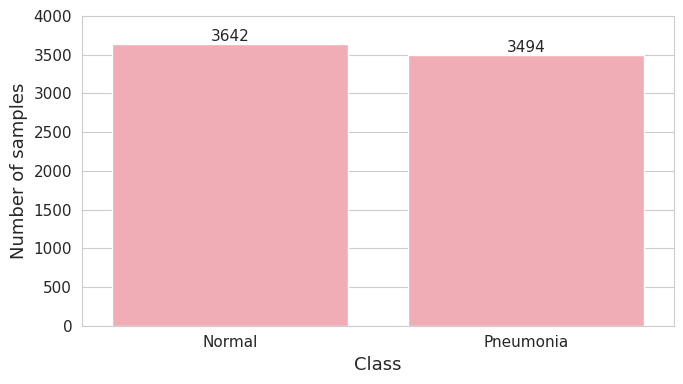

Saved histogram to: augmented_data_histograms/pneumonia_augmented_histogram.svg


/tmp/ipykernel_2807055/4139638557.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


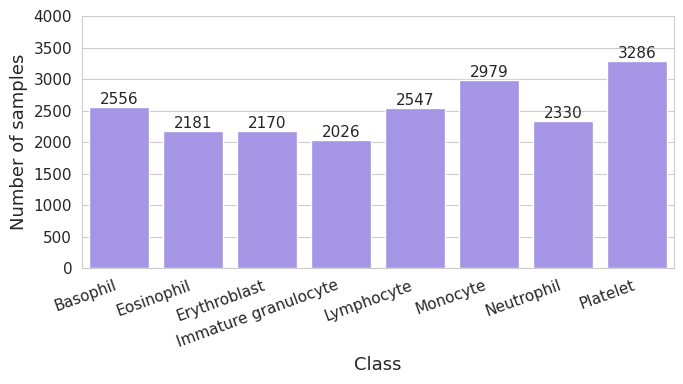

Saved histogram to: augmented_data_histograms/blood_augmented_histogram.svg


In [4]:
# ============================================================
# Import libraries
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Match preferred style
sns.set_style("whitegrid")

# Slightly larger global font sizes
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})


# ============================================================
# Create output directory
# ============================================================

OUTPUT_DIR = "augmented_data_histograms"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# Custom colors
# ============================================================

BLUE   = "#79d7fc"   # BreastMNIST
PURPLE = "#9b88f2"   # BloodMNIST
ROSE   = "#fca2ac"   # PneumoniaMNIST


# ============================================================
# Function
# ============================================================

def plot_class_distribution(
    data_path,
    label_map,
    color,
    save_name,
    figsize=(7, 4),
    rotation=0,
    y_limit=None
):

    # Load labels
    y_path = os.path.join(data_path, "Y_train_balanced.npy")
    y = np.load(y_path).flatten()

    # Count class occurrences
    unique, counts = np.unique(y, return_counts=True)

    # Create dataframe
    df = pd.DataFrame({
        "class_id": unique,
        "label": [label_map[u] for u in unique],
        "count": counts
    })

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # ========================================================
    # Barplot
    # ========================================================

    sns.barplot(
        data=df,
        x="label",
        y="count",
        ax=ax,
        color=color
    )

    # ========================================================
    # Axis labels
    # ========================================================

    ax.set_xlabel("Class")
    ax.set_ylabel("Number of samples")

    # Match original style
    ax.tick_params(axis="x", rotation=rotation)

    # Keep labels centered when not rotated
    if rotation == 0:
        ax.set_xticklabels(ax.get_xticklabels(), ha="center")
    else:
        ax.set_xticklabels(ax.get_xticklabels(), ha="right")

    # ========================================================
    # Add values above bars
    # ========================================================

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=11
        )

    # ========================================================
    # Custom y-axis upper limit
    # ========================================================

    if y_limit is not None:
        ax.set_ylim(top=y_limit)

    # Tight layout
    fig.tight_layout()

    # ========================================================
    # Save figure
    # ========================================================

    save_path = os.path.join(
        OUTPUT_DIR,
        f"{save_name}_augmented_histogram.svg"
    )

    plt.savefig(save_path, format="svg", bbox_inches="tight")

    # Show figure
    plt.show()

    print(f"Saved histogram to: {save_path}")


# ============================================================
# BreastMNIST (BLUE)
# ============================================================

breast_labels = {
    0: "Malignant",
    1: "Benign"
}

plot_class_distribution(
    data_path="BreastMNIST/processed_data",
    label_map=breast_labels,
    color=BLUE,
    save_name="breast",
    rotation=0,
    y_limit=500
)


# ============================================================
# PneumoniaMNIST (ROSE)
# ============================================================

pneumonia_labels = {
    0: "Normal",
    1: "Pneumonia"
}

plot_class_distribution(
    data_path="PneumoniaMNIST/processed_data",
    label_map=pneumonia_labels,
    color=ROSE,
    save_name="pneumonia",
    rotation=0,
    y_limit=4000
)


# ============================================================
# BloodMNIST (PURPLE)
# ============================================================

blood_labels = {
    0: "Basophil",
    1: "Eosinophil",
    2: "Erythroblast",
    3: "Immature granulocyte",
    4: "Lymphocyte",
    5: "Monocyte",
    6: "Neutrophil",
    7: "Platelet"
}

plot_class_distribution(
    data_path="BloodMNIST/processed_data",
    label_map=blood_labels,
    color=PURPLE,
    save_name="blood",
    rotation=20,
    y_limit=4000
)